# 3-RRR Spherical Parallel Mechanism - Symbolic Kinematics

**Author:** Chawin Ophaswongse  
**Date:** January 2026  
**Purpose:** Symbolic derivation and verification of forward/inverse kinematics

---

This notebook uses SymPy for symbolic computation to:
1. Derive forward kinematics equations
2. Verify the C++ implementation formulas
3. Visualize mechanism configurations
4. Generate test cases with known solutions

## 1. Setup and Imports

In [117]:
import sympy as sp
from sympy import symbols, cos, sin, Matrix, sqrt, simplify, trigsimp
from sympy import pi, atan2, acos, asin
from sympy.vector import CoordSys3D
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# import transformation calculations
from scipy.spatial.transform import Rotation as R

# Enable pretty printing
sp.init_printing(use_unicode=True)

print("SymPy version:", sp.__version__)
print("NumPy version:", np.__version__)

SymPy version: 1.14.0
NumPy version: 1.24.2


## 2. Define Symbolic Variables

### Basic Architecture Parameters for Platform joint positions
- $\eta_{i1}, \eta_{i2} = 2(i-1)\pi/3, i = 1,2,3$ ($120^\circ$ increment): Rotation around base and moving platform z-axis , respectively
- $\gamma_{i1}$, $\gamma_{i2}$: Rotation around current base and moving platform x-axis, respectively
- Rotational Sequence $R_z(\eta_{i})R_x(\gamma_{i})$

### Architecture Parameters of FK
- $\alpha_{i1}$: Proximal link angle (angle from input axis to intermediate joint)
- $\alpha_{i2}$: Distal link angle (angle from intermediate joint to output)
- $\beta_{i1}$: Base joint orientation angles
- $\beta_{i2}$: Moving platform orientation angles

### Joint Variables
- $\theta_i$: Input joint angles (actuated)

In [106]:
# Platform parameters (symbolic)
# Base platform
eta_11, eta_21, eta_31 = symbols('eta_11 eta_21 eta_31', real=True)
gamma_11, gamma_21, gamma_31 = symbols('gamma_11 gamma_21 gamma_31', real=True)

# Moving platform
eta_12, eta_22, eta_32 = symbols('eta_12 eta_22 eta_32', real=True)
gamma_12, gamma_22, gamma_32 = symbols('gamma_12 gamma_22 gamma_32', real=True)

# Architecture parameters (symbolic)
alpha_11, alpha_12, alpha_13 = symbols('alpha_11 alpha_12 alpha_13', real=True)
alpha_21, alpha_22, alpha_23 = symbols('alpha_21 alpha_22 alpha_23', real=True)
beta_11, beta_12, beta_13 = symbols('beta_11 beta_12 beta_13', real=True)
beta_21, beta_22, beta_23 = symbols('beta_21 beta_22 beta_23', real=True)

# Joint angles (input variables)
theta_1, theta_2, theta_3 = symbols('theta_1 theta_2 theta_3', real=True)

# Intermediate variables
epsilon_1, epsilon_2, epsilon_3 = symbols('epsilon_1 epsilon_2 epsilon_3', real=True)

# Group for convenience
theta = [theta_1, theta_2, theta_3]
alpha_i1 = [alpha_11, alpha_12, alpha_13]
alpha_i2 = [alpha_21, alpha_22, alpha_23]
beta_i1 = [beta_11, beta_12, beta_13]
beta_i2 = [beta_21, beta_22, beta_23]

# define rotation matrices in terms of R components
r11, r12, r13 = symbols('r11 r12 r13', real=True)
r21, r22, r23 = symbols('r21 r22 r23', real=True)
r31, r32, r33 = symbols('r31 r32 r33', real=True)
R_d = Matrix([[r11, r12, r13],
            [r21, r22, r23],
            [r31, r32, r33]])

wx, wy, wz = symbols('wx wy wz', real=True)
a1, a2, a3 = symbols('a1 a2 a3', real=True)
b1, b2, b3 = symbols('b1 b2 b3', real=True)
c1, c2, c3 = symbols('c1 c2 c3', real=True)

print("Joint angles:", theta)
print("Proximal link angles:", alpha_i1)
print("Desired Rotation Matrix R_d:", R_d)

Joint angles: [theta_1, theta_2, theta_3]
Proximal link angles: [alpha_11, alpha_12, alpha_13]
Desired Rotation Matrix R_d: Matrix([[r11, r12, r13], [r21, r22, r23], [r31, r32, r33]])


## 3. Rotation Matrices

Define basic rotation matrices for spherical kinematics.

In [136]:
def Rx(angle):
    """Rotation matrix about X-axis"""
    return Matrix([
        [1, 0, 0],
        [0, cos(angle), -sin(angle)],
        [0, sin(angle), cos(angle)]
    ])

def Ry(angle):
    """Rotation matrix about Y-axis"""
    return Matrix([
        [cos(angle), 0, sin(angle)],
        [0, 1, 0],
        [-sin(angle), 0, cos(angle)]
    ])

def Rz(angle):
    """Rotation matrix about Z-axis"""
    return Matrix([
        [cos(angle), -sin(angle), 0],
        [sin(angle), cos(angle), 0],
        [0, 0, 1]
    ])

# Display Rz as example
print("Rz(theta):")
Rz(theta_1)

Rz(theta):


⎡cos(θ₁)  -sin(θ₁)  0⎤
⎢                    ⎥
⎢sin(θ₁)  cos(θ₁)   0⎥
⎢                    ⎥
⎣   0        0      1⎦

## 4. Rodrigues' Rotation Formula

For rotating a vector $\mathbf{v}$ about axis $\mathbf{k}$ by angle $\theta$:

$$\mathbf{v}_{rot} = \mathbf{v} \cos\theta + (\mathbf{k} \times \mathbf{v}) \sin\theta + \mathbf{k}(\mathbf{k} \cdot \mathbf{v})(1 - \cos\theta)$$

In [137]:
def rodrigues_rotation(v, k, angle):
    """
    Rotate vector v about axis k by angle using Rodrigues' formula.
    
    Parameters:
    - v: 3x1 vector to rotate
    - k: 3x1 unit axis of rotation
    - angle: rotation angle
    
    Returns:
    - Rotated vector
    """
    v = Matrix(v)
    k = Matrix(k)
    
    # Cross product k x v
    k_cross_v = Matrix([
        k[1]*v[2] - k[2]*v[1],
        k[2]*v[0] - k[0]*v[2],
        k[0]*v[1] - k[1]*v[0]
    ])
    
    # Dot product k . v
    k_dot_v = k[0]*v[0] + k[1]*v[1] + k[2]*v[2]
    
    # Rodrigues' formula
    v_rot = v * cos(angle) + k_cross_v * sin(angle) + k * k_dot_v * (1 - cos(angle))
    
    return simplify(v_rot)

# Test: rotate [1, 0, 0] about z-axis by 90 degrees should give [0, 1, 0]
test_result = rodrigues_rotation([1, 0, 0], [0, 0, 1], pi/2)
print("Rotate [1,0,0] about z by 90°:")
test_result

Rotate [1,0,0] about z by 90°:


⎡0⎤
⎢ ⎥
⎢1⎥
⎢ ⎥
⎣0⎦

## 5. Intermediate Joint Axis (v-vector) Computation

**This is the critical formula that needs verification!**

The v-vector represents the direction of the intermediate joint axis after rotating the proximal link by $\theta_i$.

In [138]:
Ru1 = Rz(eta_11) * Rx(gamma_11)
u1 = Ru1 * Matrix([0, 0, 1])
Rv1 = Ru1 * Rz(theta_1) * Rx(alpha_11) 
v1 = trigsimp(Rv1 * Matrix([0, 0, 1]))
# u1, trigsimp(v1)
Rw1 = Rv1 * Rz(epsilon_1) * Rx(alpha_12)
w1 = Rw1 * Matrix([0, 0, 1])
print("Unit vector u_i and v_i along z axis for platform joint position:")
trigsimp(u1), v1

# print(v1)

Unit vector u_i and v_i along z axis for platform joint position:


⎛⎡sin(η₁₁)⋅sin(γ₁₁) ⎤  ⎡ (sin(η₁₁)⋅cos(γ₁₁)⋅cos(θ₁) + sin(θ₁)⋅cos(η₁₁))⋅sin(α₁ ↪
⎜⎢                  ⎥  ⎢                                                       ↪
⎜⎢-sin(γ₁₁)⋅cos(η₁₁)⎥, ⎢-(-sin(η₁₁)⋅sin(θ₁) + cos(η₁₁)⋅cos(γ₁₁)⋅cos(θ₁))⋅sin(α ↪
⎜⎢                  ⎥  ⎢                                                       ↪
⎝⎣     cos(γ₁₁)     ⎦  ⎣                    -sin(α₁₁)⋅sin(γ₁₁)⋅cos(θ₁) + cos(α ↪

↪ ₁) + sin(η₁₁)⋅sin(γ₁₁)⋅cos(α₁₁) ⎤⎞
↪                                 ⎥⎟
↪ ₁₁) - sin(γ₁₁)⋅cos(α₁₁)⋅cos(η₁₁)⎥⎟
↪                                 ⎥⎟
↪ ₁₁)⋅cos(γ₁₁)                    ⎦⎠

In [139]:
# double check dot product u1 . v1
u1_dot_v1 = simplify(u1.dot(v1))
u1_dot_v1

In [112]:
# find w_i in terms of R_d
w_10 = Rz(eta_12) * Rx(gamma_12) * Matrix([0, 0, 1])
w_1 = R_d * Rz(eta_12) * Rx(gamma_12) * Matrix([0, 0, 1])
w_10, w_1

⎛⎡sin(η₁₂)⋅sin(γ₁₂) ⎤  ⎡r₁₃⋅cos(γ₁₂) - (-r₁₁⋅sin(η₁₂) + r₁₂⋅cos(η₁₂))⋅sin(γ₁₂)⎤⎞
⎜⎢                  ⎥  ⎢                                                      ⎥⎟
⎜⎢-sin(γ₁₂)⋅cos(η₁₂)⎥, ⎢r₂₃⋅cos(γ₁₂) - (-r₂₁⋅sin(η₁₂) + r₂₂⋅cos(η₁₂))⋅sin(γ₁₂)⎥⎟
⎜⎢                  ⎥  ⎢                                                      ⎥⎟
⎝⎣     cos(γ₁₂)     ⎦  ⎣r₃₃⋅cos(γ₁₂) - (-r₃₁⋅sin(η₁₂) + r₃₂⋅cos(η₁₂))⋅sin(γ₁₂)⎦⎠

In [147]:
v_1 = Matrix([a1*cos(theta_1) + b1*sin(theta_1) + c1,
              a2*cos(theta_1) + b2*sin(theta_1) + c2,
              a3*cos(theta_1) + c3])
w_1 = Matrix([wx, wy, wz])
v_1_dot_w_1 = trigsimp(v_1.dot(w_1))
v_1_dot_w_1

print(v_1_dot_w_1)

wx*(a1*cos(theta_1) + b1*sin(theta_1) + c1) + wy*(a2*cos(theta_1) + b2*sin(theta_1) + c2) + wz*(a3*cos(theta_1) + c3)




### Current C++ Implementation (BUGGY):
```cpp
v_vectors[i] = {sin_alpha * sin_theta * cos_beta, 
                sin_alpha * sin_theta * sin_beta,
                cos_alpha};
```

### Problem:
When $\theta = 0$ and $\alpha = \pi/2$: produces zero vector!

### Correct Approach:
Use rotation matrix or Rodrigues' formula to transform the default intermediate axis.

In [26]:
def compute_v_vector_buggy(theta_i, alpha_i, beta_i):
    """
    BUGGY version from C++ code.
    This produces zero vectors when theta=0!
    """
    return Matrix([
        sin(alpha_i) * sin(theta_i) * cos(beta_i),
        sin(alpha_i) * sin(theta_i) * sin(beta_i),
        cos(alpha_i)
    ])

def compute_v_vector_correct(theta_i, alpha_i, beta_i):
    """
    CORRECT version using proper spherical kinematics.
    
    The intermediate joint axis v_i is computed by:
    1. Start with default axis direction based on alpha
    2. Rotate by beta about z-axis (base orientation)
    3. Rotate by theta about the input axis
    """
    # Default intermediate axis direction (when theta=0)
    # This is at angle alpha from the input axis (z-axis assumed)
    v_default = Matrix([
        sin(alpha_i),
        0,
        cos(alpha_i)
    ])
    
    # Input axis (after rotation by beta about z)
    input_axis = Matrix([0, 0, 1])  # Assuming z-axis as base input
    
    # Apply beta rotation (base joint orientation)
    R_beta = Rz(beta_i)
    v_after_beta = R_beta * v_default
    
    # The input axis direction after beta rotation
    input_axis_rotated = R_beta * input_axis
    
    # Rotate v about the input axis by theta
    # Using Rodrigues' formula
    v_final = rodrigues_rotation(v_after_beta, input_axis_rotated, theta_i)
    
    return trigsimp(v_final)

# Compare buggy vs correct for theta=0, alpha=pi/2
print("=== Testing with theta=0, alpha=pi/2, beta=0 ===")
print("\nBuggy version:")
v_buggy = compute_v_vector_buggy(0, pi/2, 0)
print(v_buggy)

print("\nCorrect version:")
v_correct = compute_v_vector_correct(0, pi/2, 0)
print(v_correct)

=== Testing with theta=0, alpha=pi/2, beta=0 ===

Buggy version:
Matrix([[0], [0], [0]])

Correct version:
Matrix([[1], [0], [0]])


## 6. Symbolic v-vector Derivation

Let's derive the general formula for the v-vector symbolically.

In [7]:
# General symbolic derivation
alpha, beta, theta_sym = symbols('alpha beta theta', real=True)

print("General v-vector formula (symbolic):")
v_general = compute_v_vector_correct(theta_sym, alpha, beta)
print("\nv =")
v_general

General v-vector formula (symbolic):

v =


⎡sin(α)⋅cos(β + θ)⎤
⎢                 ⎥
⎢sin(α)⋅sin(β + θ)⎥
⎢                 ⎥
⎣     cos(α)      ⎦

In [8]:
# Simplify each component
print("v_x =", trigsimp(v_general[0]))
print("v_y =", trigsimp(v_general[1]))
print("v_z =", trigsimp(v_general[2]))

v_x = sin(alpha)*cos(beta + theta)
v_y = sin(alpha)*sin(beta + theta)
v_z = cos(alpha)


## 7. Class I: Agile Eye Configuration

For the Agile Eye (Class I with all angles = 90°):
- $\alpha_{i1} = \alpha_{i2} = \pi/2$ for all limbs
- $\beta_{i1}$ = base joint orientations (typically 0°, 120°, 240°)
- $\beta_{i2} = \pi/2$ (orthogonal moving platform)

In [83]:
def solve_trig_equation_numerical(A, B, C):
    """
    Solve A*cos(θ) + B*sin(θ) = C numerically.
    
    Returns: List of solutions for θ (radians), or empty if no solution exists
    """
    # Check existence condition: A² + B² ≥ C²
    discriminant = A**2 + B**2 - C**2
    
    if discriminant < 0:
        return []  # No solution
    
    # Handle special case: A + C ≈ 0
    if np.abs(A + C) < 1e-10:
        if np.abs(B) < 1e-10:
            return []  # Degenerate
        t = (C - A) / (2 * B)
        return [2 * np.arctan(t)]
    
    # Quadratic solution: t = [B ± √(A² + B² - C²)] / (A + C)
    sqrt_disc = np.sqrt(discriminant)
    t1 = (B + sqrt_disc) / (A + C)
    t2 = (B - sqrt_disc) / (A + C)
    
    theta1 = 2 * np.arctan(t1)
    theta2 = 2 * np.arctan(t2)
    
    # Return unique solutions
    if np.abs(theta1 - theta2) < 1e-10:
        return [theta1]
    return [theta1, theta2]

# Test the solver
print("=" * 50)
print("IK Trigonometric Solver - Test Cases")
print("=" * 50)

test_cases = [
    (1, 0, 0.5, "cos(θ) = 0.5 → θ = ±60°"),
    (0, 1, 0.5, "sin(θ) = 0.5 → θ = 30°, 150°"),
    (1, 1, 1, "cos(θ) + sin(θ) = 1"),
    (1, 1, np.sqrt(2), "cos(θ) + sin(θ) = √2 (boundary)"),
    (1, 0, 2, "cos(θ) = 2 (no solution)"),
]

for A, B, C, desc in test_cases:
    solutions = solve_trig_equation_numerical(A, B, C)
    print(f"\n{desc}:")
    if solutions:
        for i, theta in enumerate(solutions):
            check = A * np.cos(theta) + B * np.sin(theta)
            print(f"  θ_{i+1} = {np.degrees(theta):8.2f}° | Verify: {check:.6f} ≈ {C}")
    else:
        print("  No solution exists")

IK Trigonometric Solver - Test Cases

cos(θ) = 0.5 → θ = ±60°:
  θ_1 =    60.00° | Verify: 0.500000 ≈ 0.5
  θ_2 =   -60.00° | Verify: 0.500000 ≈ 0.5

sin(θ) = 0.5 → θ = 30°, 150°:
  θ_1 =   150.00° | Verify: 0.500000 ≈ 0.5
  θ_2 =    30.00° | Verify: 0.500000 ≈ 0.5

cos(θ) + sin(θ) = 1:
  θ_1 =    90.00° | Verify: 1.000000 ≈ 1
  θ_2 =     0.00° | Verify: 1.000000 ≈ 1

cos(θ) + sin(θ) = √2 (boundary):
  No solution exists

cos(θ) = 2 (no solution):
  No solution exists


In [84]:
from sympy import atan, tan, solve, Eq

def solve_trig_equation_symbolic(A, B, C):
    """
    Solve A*cos(θ) + B*sin(θ) = C symbolically.
    Uses tangent half-angle substitution: t = tan(θ/2)
    
    Returns: List of solutions for θ
    """
    t = symbols('t', real=True)
    
    # Quadratic equation: (A + C)*t² - 2B*t + (C - A) = 0
    quadratic_eq = (A + C)*t**2 - 2*B*t + (C - A)
    
    # Solve for t
    t_solutions = solve(quadratic_eq, t)
    
    # Convert to θ = 2*atan(t)
    theta_solutions = [simplify(2 * atan(t_sol)) for t_sol in t_solutions]
    
    return theta_solutions

# Display the general solution
A_sym, B_sym, C_sym = symbols('A B C', real=True)
print("General solution for A·cos(θ) + B·sin(θ) = C:")
print("=" * 50)
solutions = solve_trig_equation_symbolic(A_sym, B_sym, C_sym)
for i, sol in enumerate(solutions):
    print(f"\nθ_{i+1} = {sol}")

General solution for A·cos(θ) + B·sin(θ) = C:

θ_1 = 2*atan((B - sqrt(A**2 + B**2 - C**2))/(A + C))

θ_2 = 2*atan((B + sqrt(A**2 + B**2 - C**2))/(A + C))


---
## 6a. IK Constraint: Trigonometric Equation Solver

The inverse kinematics constraint $\mathbf{v} \cdot \mathbf{w} = \cos(\alpha_{i2})$ leads to equations of the form:

$$A\cos\theta + B\sin\theta = C$$

This has a **closed-form analytical solution** using the **tangent half-angle substitution**.

### Theory: Tangent Half-Angle Substitution

Let $t = \tan\left(\frac{\theta}{2}\right)$, then:

$$\cos\theta = \frac{1 - t^2}{1 + t^2}, \quad \sin\theta = \frac{2t}{1 + t^2}$$

Substituting into $A\cos\theta + B\sin\theta = C$:

$$A \cdot \frac{1-t^2}{1+t^2} + B \cdot \frac{2t}{1+t^2} = C$$

Multiplying by $(1 + t^2)$ and rearranging:

$$(A + C)t^2 - 2Bt + (C - A) = 0$$

### Quadratic Solution

$$t = \frac{B \pm \sqrt{A^2 + B^2 - C^2}}{A + C}$$

### Final Answer

$$\boxed{\theta = 2\arctan(t) = 2\arctan\left(\frac{B \pm \sqrt{A^2 + B^2 - C^2}}{A + C}\right)}$$

### Existence Condition

Solutions exist only if the discriminant is non-negative:

$$A^2 + B^2 \geq C^2$$

This makes geometric sense: the "reach" $\sqrt{A^2 + B^2}$ must be at least $|C|$.

In [9]:
# Agile Eye configuration
def agile_eye_v_vectors(theta_1_val, theta_2_val, theta_3_val):
    """
    Compute v-vectors for Agile Eye configuration.
    Base orientations at 0°, 120°, 240°.
    """
    alpha_val = pi/2
    beta_vals = [0, 2*pi/3, 4*pi/3]  # 0°, 120°, 240°
    theta_vals = [theta_1_val, theta_2_val, theta_3_val]
    
    v_vectors = []
    for i in range(3):
        v_i = compute_v_vector_correct(theta_vals[i], alpha_val, beta_vals[i])
        v_vectors.append(trigsimp(v_i))
    
    return v_vectors

# Test with theta = {0, 0, 0}
print("=== Agile Eye v-vectors for theta = {0, 0, 0} ===")
v_vecs = agile_eye_v_vectors(0, 0, 0)
for i, v in enumerate(v_vecs):
    print(f"\nv_{i+1} = {v.T}")

=== Agile Eye v-vectors for theta = {0, 0, 0} ===

v_1 = Matrix([[1, 0, 0]])

v_2 = Matrix([[-1/2, sqrt(3)/2, 0]])

v_3 = Matrix([[-1/2, -sqrt(3)/2, 0]])


In [15]:
# Conaxial Design configuration
def coaxial_v_vectors(theta_1_val, theta_2_val, theta_3_val):
    """
    Compute v-vectors for Coaxial configuration.
    Base orientations at 0°, 0°, 0°.
    """
    alpha_val = pi/2
    beta_vals = [0, 0, 0]  # 0°, 0°, 0°
    theta_vals = [theta_1_val, theta_2_val, theta_3_val]
    
    v_vectors = []
    for i in range(3):
        v_i = compute_v_vector_correct(theta_vals[i], alpha_val, beta_vals[i])
        v_vectors.append(trigsimp(v_i))
    
    return v_vectors

# Test with theta = {0, 0, 0}
print("=== Coaxial v-vectors for theta = {0, 0, 0} ===")
v_vecs = coaxial_v_vectors(0, 0, 0)
for i, v in enumerate(v_vecs):
    print(f"\nv_{i+1} = {v.T}")

=== Coaxial v-vectors for theta = {0, 0, 0} ===

v_1 = Matrix([[1, 0, 0]])

v_2 = Matrix([[1, 0, 0]])

v_3 = Matrix([[1, 0, 0]])


## 8. Numerical Verification

Convert symbolic expressions to numerical values for testing.

In [10]:
def v_vector_numerical(theta_val, alpha_val, beta_val):
    """
    Numerical computation of v-vector using correct formula.
    """
    # Default intermediate axis direction
    v_default = np.array([
        np.sin(alpha_val),
        0,
        np.cos(alpha_val)
    ])
    
    # Rotation matrix about z by beta
    c_beta, s_beta = np.cos(beta_val), np.sin(beta_val)
    R_beta = np.array([
        [c_beta, -s_beta, 0],
        [s_beta, c_beta, 0],
        [0, 0, 1]
    ])
    
    v_after_beta = R_beta @ v_default
    
    # Input axis (z-axis rotated by beta)
    k = R_beta @ np.array([0, 0, 1])
    
    # Rodrigues' rotation
    c_theta, s_theta = np.cos(theta_val), np.sin(theta_val)
    k_cross_v = np.cross(k, v_after_beta)
    k_dot_v = np.dot(k, v_after_beta)
    
    v_final = v_after_beta * c_theta + k_cross_v * s_theta + k * k_dot_v * (1 - c_theta)
    
    return v_final

# Test cases
print("=== Numerical v-vector tests ===")
test_cases = [
    (0, np.pi/2, 0),           # theta=0, alpha=90°, beta=0°
    (np.pi/6, np.pi/2, 0),     # theta=30°, alpha=90°, beta=0°
    (0, np.pi/2, 2*np.pi/3),   # theta=0, alpha=90°, beta=120°
]

for theta_val, alpha_val, beta_val in test_cases:
    v = v_vector_numerical(theta_val, alpha_val, beta_val)
    print(f"theta={np.degrees(theta_val):6.1f}°, alpha={np.degrees(alpha_val):5.1f}°, beta={np.degrees(beta_val):6.1f}°")
    print(f"  v = [{v[0]:8.4f}, {v[1]:8.4f}, {v[2]:8.4f}]")
    print(f"  |v| = {np.linalg.norm(v):.6f}")
    print()

=== Numerical v-vector tests ===
theta=   0.0°, alpha= 90.0°, beta=   0.0°
  v = [  1.0000,   0.0000,   0.0000]
  |v| = 1.000000

theta=  30.0°, alpha= 90.0°, beta=   0.0°
  v = [  0.8660,   0.5000,   0.0000]
  |v| = 1.000000

theta=   0.0°, alpha= 90.0°, beta= 120.0°
  v = [ -0.5000,   0.8660,   0.0000]
  |v| = 1.000000



# Solving IK given full rotaional matrix R

Orthornormal gamma angle: 54.7356 degrees
u_1 = [u_1x, u_1y, u_1z] = [  0.0000,  -0.8165,  -0.5774]
u_2 = [u_2x, u_2y, u_2z] = [  0.7071,   0.4082,  -0.5774]
u_3 = [u_3x, u_3y, u_3z] = [ -0.7071,   0.4082,  -0.5774]

 Verifying orthonormality of u_i vectors:
u_1 · u_1 = 1.000000 (should be 1)
u_1 · u_2 = 0.000000 (should be 0)
u_1 · u_3 = -0.000000 (should be 0)
u_2 · u_2 = 1.000000 (should be 1)
u_2 · u_3 = 0.000000 (should be 0)
u_3 · u_3 = 1.000000 (should be 1)

Testing desired orientation (ZYX Euler angles): [0, 0, 0] (radians)

 Desired Rotation Matrix R_des from euler angles: [0, 0, 0] (radians)
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

 Computed w_i vectors and their norms:
w_1 = [w_1x, w_1y, w_1z] = [  0.0000,  -0.8165,   0.5774]
1.0
w_2 = [w_2x, w_2y, w_2z] = [  0.7071,   0.4082,   0.5774]
1.0
w_3 = [w_3x, w_3y, w_3z] = [ -0.7071,   0.4082,   0.5774]
1.0
Leg 1: A_1 = -0.942809, B_1 = 0.000000
  cos(alpha_1) = 0.000000
  w_i·c = 0.000000
Leg 2: A_2 = -0.942809, B_2 = 0.000000
  co

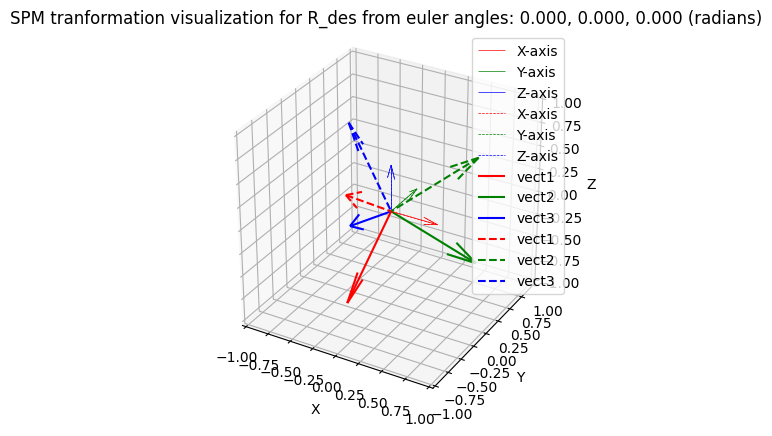


Testing desired orientation (ZYX Euler angles): [0.5235987755982988, 0.5235987755982988, 0.5235987755982988] (radians)

 Desired Rotation Matrix R_des from euler angles: [0.5235987755982988, 0.5235987755982988, 0.5235987755982988] (radians)
[[ 0.75       -0.4330127   0.5       ]
 [ 0.64951905  0.625      -0.4330127 ]
 [-0.125       0.64951905  0.75      ]]

 Computed w_i vectors and their norms:
w_1 = [w_1x, w_1y, w_1z] = [  0.6422,  -0.7603,  -0.0973]
1.0000000000000002
w_2 = [w_2x, w_2y, w_2z] = [  0.6422,   0.4644,   0.6098]
1.0
w_3 = [w_3x, w_3y, w_3z] = [ -0.4184,  -0.4541,   0.7866]
1.0000000000000002
Leg 1: A_1 = -0.359506, B_1 = 0.642229
  cos(alpha_1) = 0.000000
  w_i·c = 0.000000
Leg 2: A_2 = -0.953076, B_2 = 0.081098
  cos(alpha_2) = 0.000000
  w_i·c = 0.000000
Leg 3: A_3 = -0.720350, B_3 = 0.602499
  cos(alpha_3) = 0.000000
  w_i·c = -0.000000

solving A·cos(θ) + B·sin(θ) = C for leg 1
  A_1 = -0.359506, B_1 = 0.642229, C_1 = 0.000000
Leg 1 solutions for theta_1:
  θ_1_1 =

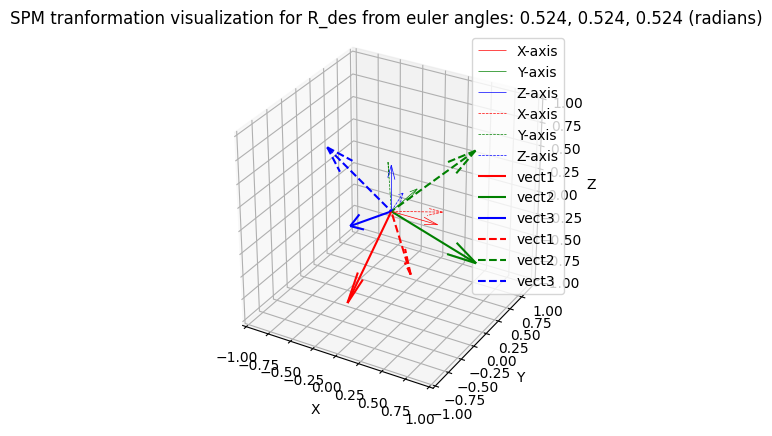


Testing desired orientation (ZYX Euler angles): [0.7853981633974483, 1.0471975511965976, 0.5235987755982988] (radians)

 Desired Rotation Matrix R_des from euler angles: [0.7853981633974483, 1.0471975511965976, 0.5235987755982988] (radians)
[[ 0.35355339 -0.35355339  0.8660254 ]
 [ 0.91855865  0.30618622 -0.25      ]
 [-0.1767767   0.88388348  0.4330127 ]]

 Computed w_i vectors and their norms:
w_1 = [w_1x, w_1y, w_1z] = [  0.7887,  -0.3943,  -0.4717]
1.0
w_2 = [w_2x, w_2y, w_2z] = [  0.6057,   0.6302,   0.4858]
1.0
w_3 = [w_3x, w_3y, w_3z] = [  0.1057,  -0.6689,   0.7358]
1.0000000000000002
Leg 1: A_1 = 0.157461, B_1 = 0.788675
  cos(alpha_1) = 0.000000
  w_i·c = 0.000000
Leg 2: A_2 = -0.881439, B_2 = 0.242922
  cos(alpha_2) = 0.000000
  w_i·c = 0.000000
Leg 3: A_3 = -0.354901, B_3 = 0.526416
  cos(alpha_3) = 0.000000
  w_i·c = -0.000000

solving A·cos(θ) + B·sin(θ) = C for leg 1
  A_1 = 0.157461, B_1 = 0.788675, C_1 = 0.000000
Leg 1 solutions for theta_1:
  θ_1_1 =   168.71° | Veri

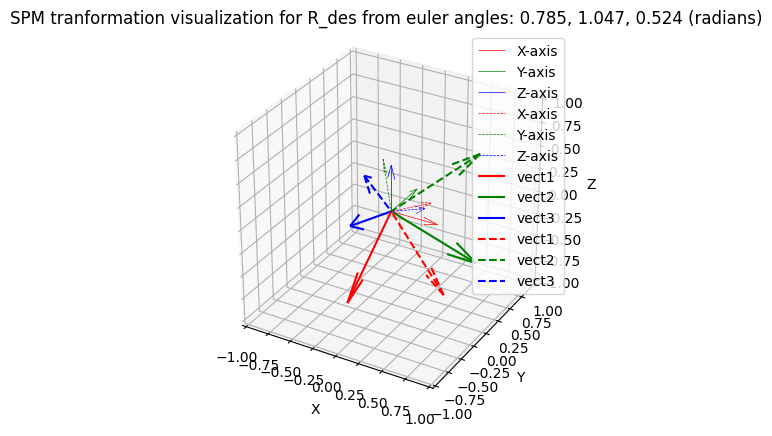


Testing desired orientation (ZYX Euler angles): [-0.7853981633974483, 0, 0] (radians)

 Desired Rotation Matrix R_des from euler angles: [-0.7853981633974483, 0, 0] (radians)
[[ 0.70710678  0.70710678  0.        ]
 [-0.70710678  0.70710678 -0.        ]
 [-0.          0.          1.        ]]

 Computed w_i vectors and their norms:
w_1 = [w_1x, w_1y, w_1z] = [ -0.5774,  -0.5774,   0.5774]
1.0
w_2 = [w_2x, w_2y, w_2z] = [  0.7887,  -0.2113,   0.5774]
0.9999999999999999
w_3 = [w_3x, w_3y, w_3z] = [ -0.2113,   0.7887,   0.5774]
1.0
Leg 1: A_1 = -0.804738, B_1 = -0.577350
  cos(alpha_1) = 0.000000
  w_i·c = 0.000000
Leg 2: A_2 = -0.804738, B_2 = -0.577350
  cos(alpha_2) = 0.000000
  w_i·c = 0.000000
Leg 3: A_3 = -0.804738, B_3 = -0.577350
  cos(alpha_3) = 0.000000
  w_i·c = 0.000000

solving A·cos(θ) + B·sin(θ) = C for leg 1
  A_1 = -0.804738, B_1 = -0.577350, C_1 = 0.000000
Leg 1 solutions for theta_1:
  θ_1_1 =   -54.34° | Verify: 0.000000 ≈ 0.000000
  θ_1_2 =   125.66° | Verify: 0.00000

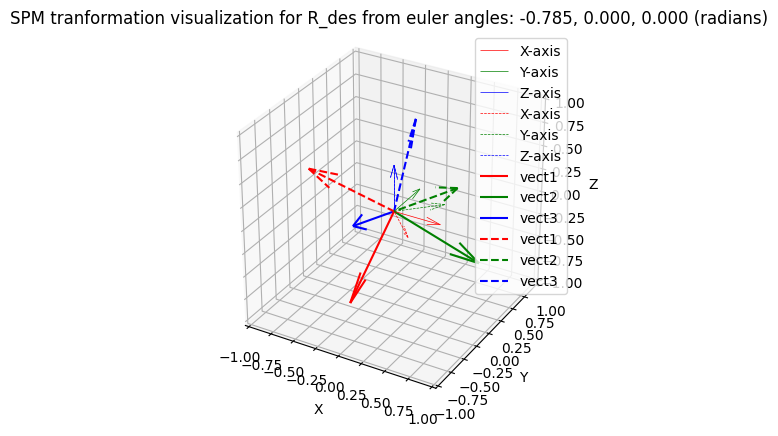


Testing desired orientation (ZYX Euler angles): [0, 0.7853981633974483, 0] (radians)

 Desired Rotation Matrix R_des from euler angles: [0, 0.7853981633974483, 0] (radians)
[[ 0.70710678  0.          0.70710678]
 [ 0.          1.          0.        ]
 [-0.70710678  0.          0.70710678]]

 Computed w_i vectors and their norms:
w_1 = [w_1x, w_1y, w_1z] = [  0.4082,  -0.8165,   0.4082]
0.9999999999999999
w_2 = [w_2x, w_2y, w_2z] = [  0.9082,   0.4082,  -0.0918]
0.9999999999999999
w_3 = [w_3x, w_3y, w_3z] = [ -0.0918,   0.4082,   0.9082]
0.9999999999999999
Leg 1: A_1 = -0.804738, B_1 = 0.408248
  cos(alpha_1) = 0.000000
  w_i·c = 0.000000
Leg 2: A_2 = -0.497060, B_2 = -0.100571
  cos(alpha_2) = 0.000000
  w_i·c = 0.000000
Leg 3: A_3 = -0.905309, B_3 = -0.307678
  cos(alpha_3) = 0.000000
  w_i·c = -0.000000

solving A·cos(θ) + B·sin(θ) = C for leg 1
  A_1 = -0.804738, B_1 = 0.408248, C_1 = 0.000000
Leg 1 solutions for theta_1:
  θ_1_1 =  -116.90° | Verify: -0.000000 ≈ 0.000000
  θ_1_2 =

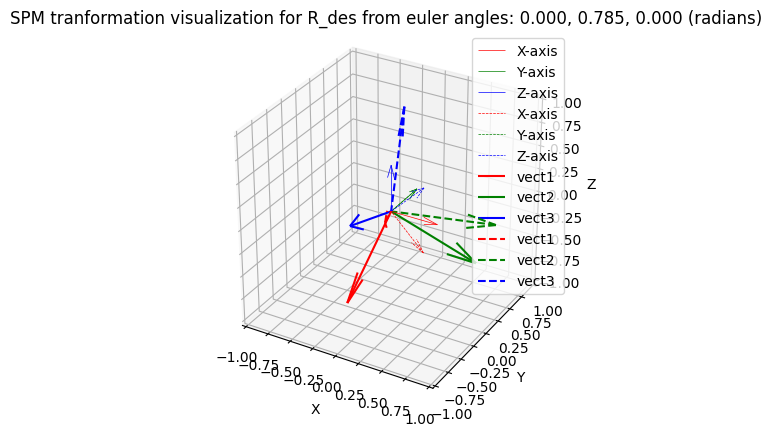

In [290]:
# define numerical parameters for testing
eta_i1 = [0, 2*np.pi/3, 4*np.pi/3]  # base platform orientations

gamma_orthonormal = np.arccos(np.sqrt(1/3))  # ~54.7356 degrees
print(f"Orthornormal gamma angle: {np.degrees(gamma_orthonormal):.4f} degrees")

eta_i2 = [0, 2*np.pi/3, 4*np.pi/3]  # moving platform orientations

# gamma_i1 = [0, 0, 0]  # base platform angles (coaxial)
# gamma_i2 = [np.pi/2, np.pi/2, np.pi/2]  # moving platform angles (coplanar moving platform)

gamma_i1 = [np.pi - gamma_orthonormal, np.pi - gamma_orthonormal, np.pi - gamma_orthonormal]  # base platform angles (orthornormal base)
gamma_i2 = [gamma_orthonormal, gamma_orthonormal, gamma_orthonormal]  # moving platform angles (orthornormal moving platform)

alpha_i1 = [np.pi/2, np.pi/2, np.pi/2]  # proximal link angles, influencing c1_i, c2_i, c3_i
alpha_i2 = [np.pi/2, np.pi/2, np.pi/2]  # distal link angles, influencing desired v·w = cos(alpha_i2)

c_eta_i1 = [np.cos(angle) for angle in eta_i1]
s_eta_i1 = [np.sin(angle) for angle in eta_i1]   
c_gamma_i1 = [np.cos(angle) for angle in gamma_i1]
s_gamma_i1 = [np.sin(angle) for angle in gamma_i1]
c_eta_i2 = [np.cos(angle) for angle in eta_i2]
s_eta_i2 = [np.sin(angle) for angle in eta_i2]  
s_gamma_i2 = [np.sin(angle) for angle in gamma_i2]
c_gamma_i2 = [np.cos(angle) for angle in gamma_i2]
c_alpha_i1 = [np.cos(angle) for angle in alpha_i1]
s_alpha_i1 = [np.sin(angle) for angle in alpha_i1]

u_i = [np.array([s_eta_i1[i]*s_gamma_i1[i], -c_eta_i1[i]*s_gamma_i1[i], c_gamma_i1[i]]) for i in range(3)]
for i in range(3):
    print(f"u_{i+1} = [u_{i+1}x, u_{i+1}y, u_{i+1}z] = [{u_i[i][0]:8.4f}, {u_i[i][1]:8.4f}, {u_i[i][2]:8.4f}]")

# verify orthonormality of u_i
print("\n Verifying orthonormality of u_i vectors:")   
for i in range(3):
    for j in range(i, 3):
        dot_product = np.dot(u_i[i], u_i[j])
        if i == j:
            print(f"u_{i+1} · u_{j+1} = {dot_product:.6f} (should be 1)")
        else:
            print(f"u_{i+1} · u_{j+1} = {dot_product:.6f} (should be 0)")

# define coefficients for v_i
a1_i = [s_eta_i1[i] * c_gamma_i1[i] * s_alpha_i1[i] for i in range(3)]
b1_i = [c_eta_i1[i] * s_alpha_i1[i] for i in range(3)]
c1_i = [s_eta_i1[i] * s_gamma_i1[i] * c_alpha_i1[i] for i in range(3)]   

a2_i = [- c_eta_i1[i] * c_gamma_i1[i] * s_alpha_i1[i] for i in range(3)]
b2_i = [s_eta_i1[i] * s_alpha_i1[i] for i in range(3)]
c2_i = [- c_eta_i1[i] * s_gamma_i1[i] * c_alpha_i1[i] for i in range(3)]

a3_i = [- s_gamma_i1[i] * s_alpha_i1[i] for i in range(3)]
b3_i = [0 for i in range(3)]
c3_i = [c_gamma_i1[i] * c_alpha_i1[i] for i in range(3)]

# define desired rotation matrix R_des (identity for testing)
# euler_angles = [np.pi/4, np.pi/3, np.pi/6]  # ZYX Euler angles in radians
# euler_angles = [-np.pi/4, 0, 0]  # ZYX Euler angles in radians
# euler_angles = [0, np.pi/4, 0]  # ZYX Euler angles in radians
euler_angles = [0,0,0]

# loop over differnet desired orientations
euler_angles_set = [
    [0, 0, 0],  
    [np.pi/6, np.pi/6, np.pi/6],
    [np.pi/4, np.pi/3, np.pi/6],
    [-np.pi/4, 0, 0],
    [0, np.pi/4, 0],
]

for euler_angles in euler_angles_set:
    print("\n" + "="*60)
    print(f"Testing desired orientation (ZYX Euler angles): {euler_angles} (radians)")
     # compute desired rotation matrix

    R_des = R.from_euler('zyx', euler_angles).as_matrix()
    print(f"\n Desired Rotation Matrix R_des from euler angles: {euler_angles} (radians)")
    print(R_des)
    w_i0 = [np.array([s_eta_i2[i]*s_gamma_i2[i], -c_eta_i2[i]*s_gamma_i2[i], c_gamma_i2[i]]) for i in range(3)]
    w_i = [R_des @ w_i0[i] for i in range(3)]
    print("\n Computed w_i vectors and their norms:")
    for i in range(3):
        print(f"w_{i+1} = [w_{i+1}x, w_{i+1}y, w_{i+1}z] = [{w_i[i][0]:8.4f}, {w_i[i][1]:8.4f}, {w_i[i][2]:8.4f}]")
        print(np.linalg.norm(w_i[i]))

    # From symbolic derivation:
    # v dot w = v_1_dot_w_1 = wx*(a1*cos(theta_1) + b1*sin(theta_1) + c1) + 
    # wy*(a2*cos(theta_1) + b2*sin(theta_1) + c2) + 
    # wz*(a3*cos(theta_1) + c3)

    # Arrange v dot w = cos(alpha_i2) -> Ai*cos(theta_i) + Bi*sin(theta_i) = Ci
    # A1 = wx*a1 + wy*a2 + wz*a3
    # B1 = wx*b1 + wy*b2 + wz*b3
    # C1 = cos(alpha_i2) - (wx*c1 + wy*c2 + wz*c3)
    A_i = [ w_i[i][0]*a1_i[i] + w_i[i][1]*a2_i[i] + w_i[i][2]*a3_i[i] for i in range(3)]
    B_i = [ w_i[i][0]*b1_i[i] + w_i[i][1]*b2_i[i] + w_i[i][2]*b3_i[i] for i in range(3)]
    for i in range(3):
        print(f"Leg {i+1}: A_{i+1} = {A_i[i]:.6f}, B_{i+1} = {B_i[i]:.6f}")
        print(f"  cos(alpha_{i+1}) = {np.cos(alpha_i2[i]):.6f}")
        print(f"  w_i·c = {w_i[i][0]*c1_i[i] + w_i[i][1]*c2_i[i] + w_i[i][2]*c3_i[i]:.6f}")
    C_i = [ np.cos(alpha_i2[i]) - (w_i[i][0]*c1_i[i] + w_i[i][1]*c2_i[i] + w_i[i][2]*c3_i[i]) for i in range(3)]

    # compute joint angles theta_i solutions for each leg 
    for i in range(3):
        print(f"\nsolving A·cos(θ) + B·sin(θ) = C for leg {i+1}")
        print(f"  A_{i+1} = {A_i[i]:.6f}, B_{i+1} = {B_i[i]:.6f}, C_{i+1} = {C_i[i]:.6f}")
        sols = solve_trig_equation_numerical(A_i[i], B_i[i], C_i[i])
        print(f"Leg {i+1} solutions for theta_{i+1}:")
        if sols:
            for j, theta_sol in enumerate(sols):
                check = A_i[i] * np.cos(theta_sol) + B_i[i] * np.sin(theta_sol)
                print(f"  θ_{i+1}_{j+1} = {np.degrees(theta_sol):8.2f}° | Verify: {check:.6f} ≈ {C_i[i]:.6f}")
        else:
            print("  No solution exists")

    # visualization of the platform and joint vectors
    plot_spsm_transformation(u_i, w_i, R_des, euler_angles)


## 9. Visualization

3D plot of the mechanism configuration.

In [278]:
import numpy as np
import matplotlib.pyplot as plt

def _plot_coordinate_frame(ax, R, origin=np.zeros(3), length=1.0, **kwargs):
    """
    Plot a 3D coordinate frame given rotation matrix R and origin.
    """
    origin = np.asarray(origin).flatten()
    x_axis = R[:, 0] * length
    y_axis = R[:, 1] * length
    z_axis = R[:, 2] * length

    linewidth = 0.5
    ax.quiver(
        origin[0], origin[1], origin[2],
        x_axis[0], x_axis[1], x_axis[2],
        color='r', label='X-axis', linewidth=linewidth, **kwargs
    )
    ax.quiver(
        origin[0], origin[1], origin[2],
        y_axis[0], y_axis[1], y_axis[2],
        color='g', label='Y-axis', linewidth=linewidth, **kwargs
    )
    ax.quiver(
        origin[0], origin[1], origin[2],
        z_axis[0], z_axis[1], z_axis[2],
        color='b', label='Z-axis', linewidth=linewidth, **kwargs
    )

def _plot_single_quiver(ax, v, color='b', label=None, **kwargs):
    """
    Plot a single 3D quiver on an existing axis.
    """
    origin = np.zeros(3)
    v = np.asarray(v).flatten()

    ax.quiver(
        origin[0], origin[1], origin[2],
        v[0], v[1], v[2],
        length=1.0, normalize=True,
        color=color, label=label, **kwargs
    )


def plot_unit_vectors(ax, v, linestyle='-'):
    """
    Plot a 3D unit vector or a list of unit vectors in the same figure.
    """
    # If v is a list/array of vectors (Nx3)
    v = np.asarray(v)

    if v.ndim == 2:
        colors = ['r', 'g', 'b', 'c', 'm', 'y']
        for i, vi in enumerate(v):
            _plot_single_quiver(
                ax, vi,
                color=colors[i % len(colors)],
                label=f"vect{i+1}",
                linestyle=linestyle
            )
        ax.legend()
    else:
        _plot_single_quiver(ax, v, color='b')

    # Axis formatting
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_zlim([-1, 1])
    ax.set_box_aspect([1, 1, 1])

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

def plot_spsm_transformation(u_i, w_i, R_des, euler_angles):
    """
    Plot the SPM transformation including base frame, desired frame,
    and unit vectors u_i and w_i.
    """
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    _plot_coordinate_frame(ax, np.eye(3), length=0.5)
    _plot_coordinate_frame(ax, R_des, length=0.5, linestyle='--')   
    # Example usage: plot the computed u_i and w_i vectors
    print("Plotting u_i vectors...")
    plot_unit_vectors(ax=ax, v=u_i)

    print("Plotting w_i vectors...")
    plot_unit_vectors(ax=ax, v=w_i, linestyle='--')

    ax.set_title(f"SPM tranformation visualization for R_des from euler angles: {euler_angles[0]:.3f}, {euler_angles[1]:.3f}, {euler_angles[2]:.3f} (radians)")

    plt.show()


NameError: name 'v_vector_numerical' is not defined

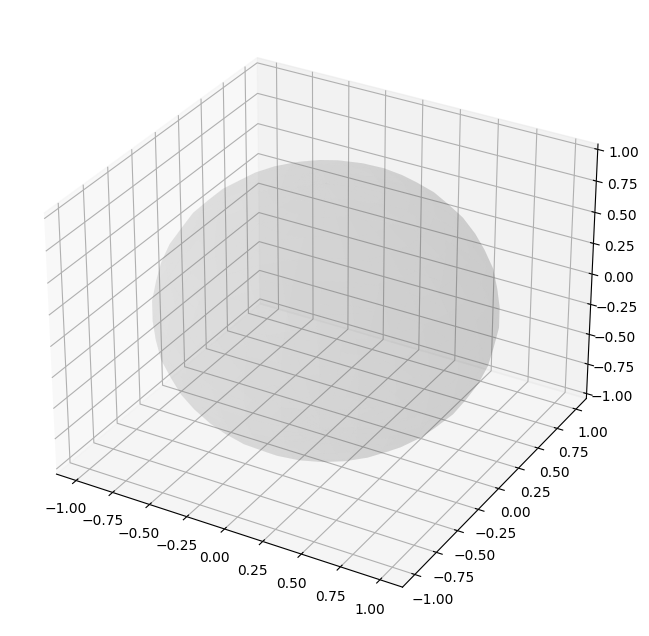

In [229]:

def plot_mechanism(theta_vals, alpha_val=np.pi/2, title="3-RRR SPM Configuration"):
    """
    Visualize the mechanism with given joint angles.
    """
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Base orientations (0°, 120°, 240°)
    beta_vals = [0, 2*np.pi/3, 4*np.pi/3]
    colors = ['red', 'green', 'blue']
    
    # Plot unit sphere (lightly)
    u = np.linspace(0, 2 * np.pi, 30)
    v = np.linspace(0, np.pi, 20)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_surface(x, y, z, alpha=0.1, color='gray')
    
    # Plot each limb
    for i in range(3):
        # Input axis direction
        c_beta, s_beta = np.cos(beta_vals[i]), np.sin(beta_vals[i])
        R_beta = np.array([[c_beta, -s_beta, 0], [s_beta, c_beta, 0], [0, 0, 1]])
        input_axis = R_beta @ np.array([0, 0, 1])
        
        # v-vector
        v_i = v_vector_numerical(theta_vals[i], alpha_val, beta_vals[i])
        
        # Plot input axis
        ax.quiver(0, 0, 0, input_axis[0], input_axis[1], input_axis[2], 
                  color=colors[i], alpha=0.5, arrow_length_ratio=0.1, linewidth=2)
        
        # Plot v-vector (intermediate joint axis)
        ax.quiver(0, 0, 0, v_i[0], v_i[1], v_i[2], 
                  color=colors[i], arrow_length_ratio=0.1, linewidth=3,
                  label=f'Limb {i+1}: θ={np.degrees(theta_vals[i]):.1f}°')
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title)
    ax.legend()
    ax.set_box_aspect([1,1,1])
    
    plt.tight_layout()
    plt.show()

# Plot with theta = {0, 0, 0}
plot_mechanism([0, 0, 0], title="Home Position (θ = {0, 0, 0})")

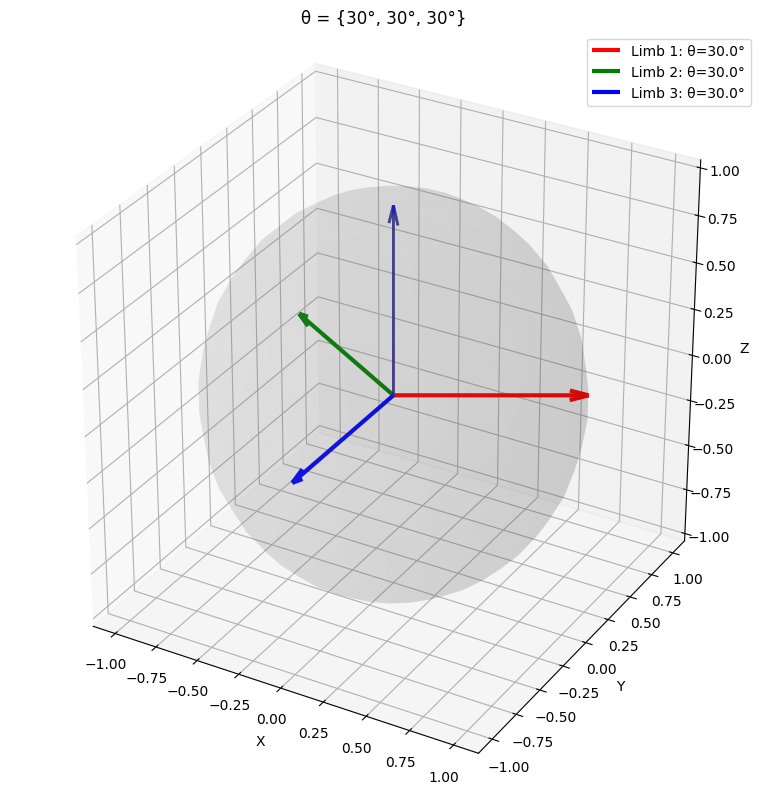

In [ ]:
# Plot with different joint angles
plot_mechanism([np.pi/6, np.pi/6, np.pi/6], title="θ = {30°, 30°, 30°}")

## 10. Generate C++ Code

Export the correct formula for use in C++.

In [ ]:
print("""
// CORRECT v-vector computation for C++
// Replace the buggy formula in forward_kinematics.cpp

Vector3 compute_v_vector(double theta, double alpha, double beta) {
    // Default intermediate axis (when theta=0)
    double v_default_x = std::sin(alpha);
    double v_default_y = 0.0;
    double v_default_z = std::cos(alpha);
    
    // Apply beta rotation (Rz)
    double c_beta = std::cos(beta);
    double s_beta = std::sin(beta);
    double vx = c_beta * v_default_x - s_beta * v_default_y;
    double vy = s_beta * v_default_x + c_beta * v_default_y;
    double vz = v_default_z;
    
    // Input axis is [0, 0, 1] (z-axis), which doesn't change under Rz
    // So we rotate v about z-axis by theta using Rodrigues' formula
    // For rotation about z: v_rot = v*cos(theta) + (z x v)*sin(theta) + z*(z.v)*(1-cos(theta))
    // z x v = [-vy, vx, 0]
    // z.v = vz
    
    double c_theta = std::cos(theta);
    double s_theta = std::sin(theta);
    
    double v_rot_x = vx * c_theta - vy * s_theta;
    double v_rot_y = vy * c_theta + vx * s_theta;
    double v_rot_z = vz;  // z-component unchanged for rotation about z
    
    return {v_rot_x, v_rot_y, v_rot_z};
}
""")


// CORRECT v-vector computation for C++
// Replace the buggy formula in forward_kinematics.cpp

Vector3 compute_v_vector(double theta, double alpha, double beta) {
    // Default intermediate axis (when theta=0)
    double v_default_x = std::sin(alpha);
    double v_default_y = 0.0;
    double v_default_z = std::cos(alpha);
    
    // Apply beta rotation (Rz)
    double c_beta = std::cos(beta);
    double s_beta = std::sin(beta);
    double vx = c_beta * v_default_x - s_beta * v_default_y;
    double vy = s_beta * v_default_x + c_beta * v_default_y;
    double vz = v_default_z;
    
    // Input axis is [0, 0, 1] (z-axis), which doesn't change under Rz
    // So we rotate v about z-axis by theta using Rodrigues' formula
    // For rotation about z: v_rot = v*cos(theta) + (z x v)*sin(theta) + z*(z.v)*(1-cos(theta))
    // z x v = [-vy, vx, 0]
    // z.v = vz
    
    double c_theta = std::cos(theta);
    double s_theta = std::sin(theta);
    
    double v_rot_x = vx * c_theta - vy * s

## 11. TODO: Further Work

- [ ] Implement full FK equation derivation (quadratic/quartic formulation)
- [ ] Derive IK closed-form solution
- [ ] Add workspace analysis
- [ ] Generate test cases with known FK solutions
- [ ] Compare Class I, II, III architectures
- [ ] Add singularity analysis

In [ ]:
print("Notebook complete! Use these derivations to fix the C++ implementation.")

Notebook complete! Use these derivations to fix the C++ implementation.
